<a href="https://colab.research.google.com/github/hj245668/ds6_warpUp/blob/main/NCsoft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[데이터수집] 1(5년 주가 데이터) + 2(5년 주가데이터 기술적지표생성) +3 (뉴스 크롤링) + 4(뉴스 이벤트 스코어 산출)

In [27]:
!pip install finance-datareader pandas matplotlib --quiet
import FinanceDataReader as fdr
import pandas as pd
from datetime import datetime

code = '036570'
start = '2020-01-01'
end = datetime.now().strftime('%Y-%m-%d')

df = fdr.DataReader(code, start, end)
df.to_csv('/content/ncsoft_5y.csv', index=True)

print(f"기간: {df.index.min()} ~ {df.index.max()} | 총 {len(df)}행")
print(df.info())
print(df.describe())
print(df.head())


기간: 2020-01-02 00:00:00 ~ 2025-10-31 00:00:00 | 총 1432행
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1432 entries, 2020-01-02 to 2025-10-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1432 non-null   int64  
 1   High    1432 non-null   int64  
 2   Low     1432 non-null   int64  
 3   Close   1432 non-null   int64  
 4   Volume  1432 non-null   int64  
 5   Change  1432 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 78.3 KB
None
               Open          High           Low         Close        Volume  \
count  1.432000e+03  1.432000e+03  1.432000e+03  1.432000e+03  1.432000e+03   
mean   4.596744e+05  4.676881e+05  4.524402e+05  4.595936e+05  1.288400e+05   
std    2.623608e+05  2.665172e+05  2.584333e+05  2.624474e+05  1.484532e+05   
min    1.353000e+05  1.361000e+05  1.346000e+05  1.358000e+05  2.926800e+04   
25%    2.090000e+05  2.130000e+05  2.055000e+05  2.085000e+05  7.283075e+

In [30]:
# 2(5년 주가데이터 기술적지표생성) - 피처링

import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import pandas_ta as ta
from datetime import datetime

code = '036570'
df = fdr.DataReader(code, '2020-01-01', datetime.now().strftime('%Y-%m-%d'))

df['Return_1d'] = df['Close'].pct_change()
df['Return_5d'] = df['Close'].pct_change(5)
df['MA5'] = df['Close'].rolling(5).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['MA60'] = df['Close'].rolling(60).mean()
df['Volatility_20d'] = df['Return_1d'].rolling(20).std()
df['Volume_Change'] = df['Volume'].pct_change(5)
df['RSI'] = ta.rsi(df['Close'], length=14)
df['MACD'] = ta.macd(df['Close'])['MACD_12_26_9']
df['Signal'] = ta.macd(df['Close'])['MACDs_12_26_9']
df['High_52w'] = df['Close'].rolling(252).max()
df['Low_52w'] = df['Close'].rolling(252).min()
df['Position_52w'] = (df['Close'] - df['Low_52w']) / (df['High_52w'] - df['Low_52w'])
df['ATR'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
df = df.dropna()

print(df.tail())


              Open    High     Low   Close  Volume    Change  Return_1d  \
Date                                                                      
2025-10-27  204000  214500  204000  213000  117472  0.046683   0.046683   
2025-10-28  216000  224500  213500  217500  177875  0.021127   0.021127   
2025-10-29  221500  224000  215500  221000  108328  0.016092   0.016092   
2025-10-30  220500  227000  218500  221500  107947  0.002262   0.002262   
2025-10-31  222000  227000  220000  220500   76909 -0.004515  -0.004515   

            Return_5d       MA5      MA20           MA60  Volatility_20d  \
Date                                                                       
2025-10-27   0.054455  206400.0  212850.0  207965.000000        0.020304   
2025-10-28   0.058394  208800.0  212225.0  208356.666667        0.020600   
2025-10-29   0.070218  211700.0  211900.0  208826.666667        0.020910   
2025-10-30   0.088452  215300.0  211800.0  209286.666667        0.020561   
2025-10-31   0.083

In [ ]:
"""
fdr.DataReader(code, '2020-01-01', today)	FinanceDataReader로 주가 불러오기	엔씨소프트 일자별 시세 (Open, High, Low, Close, Volume 등)
Return_1d, Return_5d	수익률	전일 대비, 5일 대비 가격 변동률
MA5, MA20, MA60	이동평균선	단기(5일), 중기(20일), 장기(60일) 평균가격
Volatility_20d	20일 표준편차	최근 1개월간 변동성
Volume_Change	거래량 변화율	최근 5일 동안 거래량 증감률
RSI	Relative Strength Index	과매수·과매도 판단용 지표 (70↑ 과열 / 30↓ 침체)
MACD, Signal	이동평균 수렴확산	추세 전환 시점 탐지용 (MACD선과 Signal선 교차)
High_52w, Low_52w	52주 최고/최저가	최근 1년간 최고·최저 가격
Position_52w	현재가 위치 비율	1년에 비해 지금 가격이 얼마나 높은가
ATR	Average True Range	변동폭 지표 — 리스크/진입 타이밍 참고용
df = df.dropna()	결측치 제거	계산 중 NaN 제거 (초기 구간)
"""


In [29]:
df.head()

,Open,High,Low,Close,Volume,Change,Return_1d,Return_5d,MA5,MA20,MA60,Volatility_20d,Volume_Change,RSI,MACD,Signal,High_52w,Low_52w,Position_52w,ATR
Date,,,,,,,,,,,,,,,,,,,,
2021-01-07,962000,963000,939000,947000,118410,-0.006296,-0.006296,0.037240,958800.0,899850.0,839433.333333,0.016567,-0.153803,66.088828,30641.885911,24446.612657,995000.0,530000.0,0.896774,25323.492845
2021-01-08,956000,1000000,949000,995000,198693,0.050686,0.050686,0.068743,971600.0,905900.0,843450.000000,0.019537,0.674375,73.682093,33895.728578,26336.435841,995000.0,530000.0,1.000000,27300.386213
2021-01-11,993000,1006000,955000,978000,220317,-0.017085,-0.017085,0.000000,971600.0,910850.0,847216.666667,0.020249,0.451459,67.884487,34702.634046,28009.675482,995000.0,530000.0,0.963441,28993.215769
2021-01-12,963000,969000,926000,947000,192743,-0.031697,-0.031697,-0.038579,964000.0,914300.0,850500.000000,0.021868,0.568738,58.798894,32466.418853,28901.024156,995000.0,530000.0,0.896774,30636.557500
2021-01-13,946000,955000,933000,940000,123066,-0.007392,-0.007392,-0.013641,961400.0,916900.0,853383.333333,0.021937,-0.272917,56.945519,29786.006166,29078.020558,995000.0,530000.0,0.881720,30019.660536


1. 뉴스 데이터 크롤링
2. 엔씨소프트 주가 및 피처데이터 저장
3. 데이터정합성확인
4. 날짜 포맷 동일
5. 에씨 소프트만 필터링
6. 병합 준비 완료

In [33]:
# 3 (뉴스 크롤링)
# 1 RSS 기반 뉴스 크롤링

!pip install feedparser pandas tqdm urllib3 --quiet
import feedparser, pandas as pd, time, urllib.parse
from datetime import datetime
from tqdm import tqdm

# ----------------------------------------------
#  기본 설정
companies = {
    "엔씨소프트": "036570",
}

keywords = ["신작 출시", "AI", "실적 발표", "투자", "리뉴얼", "MOU"]
results = []
#
# ----------------------------------------------
#  네이버 뉴스 크롤링 함수

def crawl_rss(company, keyword):
    query = f"{company} {keyword}"
    encoded_query = urllib.parse.quote(query)  # 공백, 한글 URL 인코딩
    rss_url = f"https://news.google.com/rss/search?q={encoded_query}&hl=ko&gl=KR&ceid=KR:ko"

    feed = feedparser.parse(rss_url)
    for entry in feed.entries:
        try:
            title = entry.title
            link = entry.link
            pub_date = datetime(*entry.published_parsed[:6])
        except Exception:
            continue

        results.append({
            "기업명": company,
            "키워드": keyword,
            "날짜": pub_date,
            "제목": title,
            "링크": link
        })

# ----------------------------------------------
# 실행
for company in tqdm(companies.keys(), desc="기업별 진행중"):
    for keyword in keywords:
        crawl_rss(company, keyword)
        time.sleep(0.5)

# ----------------------------------------------
# 결과 DataFrame 및 저장
df_news = pd.DataFrame(results)
df_news = df_news.drop_duplicates(subset=["기업명", "제목"])
df_news = df_news.sort_values("날짜", ascending=False)

file_path = "/content/game_companies_news_rss.csv"
df_news.to_csv(file_path, index=False, encoding="utf-8-sig")

print(f"총 {len(df_news)}건 저장 완료")
print(df_news.head(10))


기업별 진행중: 100%|██████████| 1/1 [00:06<00:00,  6.15s/it]

총 478건 저장 완료
       기업명    키워드                  날짜  \
118  엔씨소프트     AI 2025-10-31 08:36:00   
0    엔씨소프트  신작 출시 2025-10-31 08:10:41   
104  엔씨소프트     AI 2025-10-31 08:08:00   
108  엔씨소프트     AI 2025-10-31 05:25:51   
137  엔씨소프트     AI 2025-10-31 02:51:13   
100  엔씨소프트     AI 2025-10-31 01:42:23   
109  엔씨소프트     AI 2025-10-31 00:42:00   
113  엔씨소프트     AI 2025-10-31 00:41:00   
128  엔씨소프트     AI 2025-10-31 00:32:00   
110  엔씨소프트     AI 2025-10-31 00:23:55   

                                                    제목  \
118     게임 좋아하던 학생, 엔씨 AI 팀장으로…AI로 1분만에 만든 3D 세계 - 네이트   
0    '소프트' 지우고 '엔씨'로 사명 바꾼다, 김택진 게임사 넘어 AI사업 영역으로 -...   
104                  NC AI, 軍에 기술이전…유·무인 전투체계 구축 - 네이트   
108      AI로 ‘자주국방’ 강국 만든다… 엔씨 AI, 육군과 전략적 업무협약 - IT조선   
137  [게임가 엿보기] 님블뉴런, '이터널 리턴' 신규 캐릭터 ‘블레어’ 출시 - 녹색경제신문   
100          NC AI, 육군 '유무인 복합전투체계' AI 개발 참여 - 글로벌이코노믹   
109  'NC AI', 게임 AI 기술 통해 국방을 혁신하다…'미래 강군' 건설 핵심 파트...   
113  NC AI, 게임 AI 기술 통해 국방을 혁신하다…미래 강군 건설 핵심 파트너로 -...   
128          

In [34]:
df_news.head()

,기업명,키워드,날짜,제목,링크
118,엔씨소프트,AI,2025-10-31 08:36:00,"게임 좋아하던 학생, 엔씨 AI 팀장으로…AI로 1분만에 만든 3D 세계 - 네이트",https://news.google.com/rss/articles/CBMiU0FVX...
0,엔씨소프트,신작 출시,2025-10-31 08:10:41,"'소프트' 지우고 '엔씨'로 사명 바꾼다, 김택진 게임사 넘어 AI사업 영역으로 -...",https://news.google.com/rss/articles/CBMic0FVX...
104,엔씨소프트,AI,2025-10-31 08:08:00,"NC AI, 軍에 기술이전…유·무인 전투체계 구축 - 네이트",https://news.google.com/rss/articles/CBMiU0FVX...
108,엔씨소프트,AI,2025-10-31 05:25:51,"AI로 ‘자주국방’ 강국 만든다… 엔씨 AI, 육군과 전략적 업무협약 - IT조선",https://news.google.com/rss/articles/CBMicEFVX...
137,엔씨소프트,AI,2025-10-31 02:51:13,"[게임가 엿보기] 님블뉴런, '이터널 리턴' 신규 캐릭터 ‘블레어’ 출시 - 녹색경제신문",https://news.google.com/rss/articles/CBMiaEFVX...


next : 뉴스 이벤트 스코어 + 주가 데이터 병합 + 예측모델 학습”
* step 1 이벤트 스코어 계산	뉴스 키워드별 가중치(AI=2.0, 신작=1.5 등) 부여
* step 2 주가 데이터 병합	/content/ncsoft_features.csv (또는 pykrx로 불러온 주가 데이터) 와 날짜 매칭
* step 3 확률 모델 예측	XGBoost/RandomForest로 “2개월 내 최고가 갱신 확률” 예측

In [35]:
#  4(뉴스 이벤트 스코어 산출)
# Step 2. 뉴스이벤트 스코어 생성

import pandas as pd
from datetime import timedelta

# 뉴스 데이터 불러오기
df_news = pd.read_csv("/content/game_companies_news_rss.csv", parse_dates=["날짜"])

# 뉴스 키워드별 가중치 설정
def event_weight(keyword):
    if "AI" in keyword: return 2.0
    elif "신작" in keyword or "출시" in keyword: return 1.5
    elif "실적" in keyword: return 1.2
    elif "투자" in keyword: return 1.0
    elif "MOU" in keyword or "리뉴얼" in keyword: return 0.8
    else: return 0.5

df_news["Event_Score"] = df_news["키워드"].apply(event_weight)

# 기업별 날짜별 스코어 합산
daily_score = (
    df_news.groupby(["기업명", df_news["날짜"].dt.date])["Event_Score"]
    .sum()
    .reset_index()
    .rename(columns={"날짜": "Date"})
)

daily_score.to_csv("/content/daily_event_score.csv", index=False, encoding="utf-8-sig")
print(f"이벤트 스코어 요약 저장 완료 ({len(daily_score)}건)")
print(daily_score.head(10))


이벤트 스코어 요약 저장 완료 (159건)
     기업명        Date  Event_Score
0  엔씨소프트  2006-04-04          0.8
1  엔씨소프트  2012-08-01          0.8
2  엔씨소프트  2016-09-30          0.8
3  엔씨소프트  2017-04-26          0.8
4  엔씨소프트  2018-03-14          1.6
5  엔씨소프트  2018-12-07          0.8
6  엔씨소프트  2019-06-05          2.4
7  엔씨소프트  2019-10-18          0.8
8  엔씨소프트  2020-01-07          4.0
9  엔씨소프트  2020-02-13          0.8


In [36]:
# 5. 데이터 병합 : 날짜기준
import pandas as pd

# 주가 + 기술지표 데이터 불러오기
price_df = pd.read_csv('/content/ncsoft_features.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'])

# 뉴스 이벤트 스코어 데이터 불러오기
event_df = pd.read_csv('/content/daily_event_score.csv')
event_df['Date'] = pd.to_datetime(event_df['Date'])

# 날짜 기준 병합
merged = pd.merge(price_df, event_df, on='Date', how='left')

# 결측치(뉴스 없는 날)는 0으로 대체
merged['Event_Score'] = merged['Event_Score'].fillna(0)

# 병합 결과 확인 및 저장
merged.to_csv('/content/ncsoft_merged.csv', index=False, encoding='utf-8-sig')
print(f"병합 완료: {merged.shape[0]}행 × {merged.shape[1]}열")
print(merged[['Date','Close','Event_Score']].tail(10))

병합 완료: 1181행 × 23열
           Date   Close  Event_Score
1171 2025-10-20  202000         11.7
1172 2025-10-21  205500          5.8
1173 2025-10-22  206500         12.8
1174 2025-10-23  203500         15.5
1175 2025-10-24  203500         10.3
1176 2025-10-27  213000         12.8
1177 2025-10-28  217500         17.5
1178 2025-10-29  221000          9.5
1179 2025-10-30  221500         22.0
1180 2025-10-31  220500         25.5


In [38]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1181 non-null   datetime64[ns]
 1   Open            1181 non-null   int64         
 2   High            1181 non-null   int64         
 3   Low             1181 non-null   int64         
 4   Close           1181 non-null   int64         
 5   Volume          1181 non-null   int64         
 6   Change          1181 non-null   float64       
 7   Return_1d       1181 non-null   float64       
 8   Return_5d       1181 non-null   float64       
 9   MA5             1181 non-null   float64       
 10  MA20            1181 non-null   float64       
 11  MA60            1181 non-null   float64       
 12  Volatility_20d  1181 non-null   float64       
 13  Volume_Change   1181 non-null   float64       
 14  RSI             1181 non-null   float64       
 15  MACD

In [39]:
# 6. 정규성 & 등분산성 검정
from scipy.stats import shapiro, levene

num_cols = merged.select_dtypes(include='number').columns

# 정규성 검정 (Shapiro–Wilk)
for col in num_cols:
    stat, p = shapiro(merged[col].dropna().sample(min(5000, len(merged[col])), random_state=42))
    print(f"[정규성] {col}: p={p:.4f} → {'정규' if p>0.05 else '비정규'}")

# 등분산성 검정 (Levene)
group1 = merged[merged['Event_Score'] > merged['Event_Score'].median()]
group2 = merged[merged['Event_Score'] <= merged['Event_Score'].median()]

for col in num_cols:
    stat, p = levene(group1[col].dropna(), group2[col].dropna())
    print(f"[등분산성] {col}: p={p:.4f} → {'등분산' if p>0.05 else '이분산'}")


[정규성] Open: p=0.0000 → 비정규
[정규성] High: p=0.0000 → 비정규
[정규성] Low: p=0.0000 → 비정규
[정규성] Close: p=0.0000 → 비정규
[정규성] Volume: p=0.0000 → 비정규
[정규성] Change: p=0.0000 → 비정규
[정규성] Return_1d: p=0.0000 → 비정규
[정규성] Return_5d: p=0.0000 → 비정규
[정규성] MA5: p=0.0000 → 비정규
[정규성] MA20: p=0.0000 → 비정규
[정규성] MA60: p=0.0000 → 비정규
[정규성] Volatility_20d: p=0.0000 → 비정규
[정규성] Volume_Change: p=0.0000 → 비정규
[정규성] RSI: p=0.0000 → 비정규
[정규성] MACD: p=0.0000 → 비정규
[정규성] Signal: p=0.0000 → 비정규
[정규성] High_52w: p=0.0000 → 비정규
[정규성] Low_52w: p=0.0000 → 비정규
[정규성] Position_52w: p=0.0000 → 비정규
[정규성] ATR: p=0.0000 → 비정규
[정규성] Event_Score: p=0.0000 → 비정규
[등분산성] Open: p=0.0000 → 이분산
[등분산성] High: p=0.0000 → 이분산
[등분산성] Low: p=0.0000 → 이분산
[등분산성] Close: p=0.0000 → 이분산
[등분산성] Volume: p=0.2444 → 등분산
[등분산성] Change: p=0.9816 → 등분산
[등분산성] Return_1d: p=0.9816 → 등분산
[등분산성] Return_5d: p=0.2612 → 등분산
[등분산성] MA5: p=0.0000 → 이분산
[등분산성] MA20: p=0.0000 → 이분산
[등분산성] MA60: p=0.0000 → 이분산
[등분산성] Volatility_20d: p=0.0564 → 등분산
[등분산성] Volume_Change

"""
1. 정규성 검정 (Shapiro–Wilk Test)
대부분의 p-value < 0.05 → “비정규 분포”
즉, 변수들이 정규분포(가우시안)를 따르지 않아요.
의미
주가, 거래량, RSI, MACD 등은 비선형적 특성을 지님
로그 변환, MinMax 스케일링, RobustScaler 등을 고려해야 함
통계적 분석(t-test, ANOVA 등)보단 트리 기반 모델 (XGBoost, RF) 이 적합

2. 등분산성 검정 (Levene Test)
일부 변수는 등분산(p>0.05),
다수 변수는 이분산(p<0.05) — 특히 Event_Score 관련
의미
뉴스 이벤트 스코어(Event_Score)가 존재할 때
→ 변동성이 크게 달라진다.
즉, 뉴스 이벤트가 있는 날은 주가 변동성(Volatility_20d)거래량 변화(Volume_Change) 가 급격히 증가하는 패턴을 보임.

결론
뉴스의 존재가 시장 반응(변동성)에 영향을 준다는 통계적 근거 확보
“Event_Score → Volatility / Return 영향” 모델로 확장 가능
"""

Volatility_20d	0.0564	등분산(경계값 근처)	뉴스 유무에 따라 변동성 차이가 약간 있음
Volume_Change	0.0076	❗이분산	뉴스 유무에 따라 거래량 분산이 유의하게 다름
Return_1d	0.9816	등분산	뉴스 유무에 따라 1일 수익률 분산 차이 거의 없음
Event_Score	0.0000	이분산	(당연히 스코어 기반 분산 크기 차이 존재)

“거래량 변화”가 이분산이라는 의미
✔️ 해석 논리

Levene Test는 “분산의 차이”를 보니까
Volume_Change에서 p-value = 0.0076 < 0.05 → 이분산

즉,

“뉴스가 있는 날(이벤트 발생일)”과
“뉴스가 없는 날(조용한 날)”의 거래량 변화 폭이 통계적으로 다르다”

→ 뉴스가 있는 날은 거래량 변화의 분포 폭(variance)이 훨씬 넓다
→ 즉, 거래량이 급증하거나 급감하는 극단적 움직임이 많다.

/tmp/ipython-input-3188445633.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Event_Flag', y='Volume_Change', data=merged, palette='coolwarm')


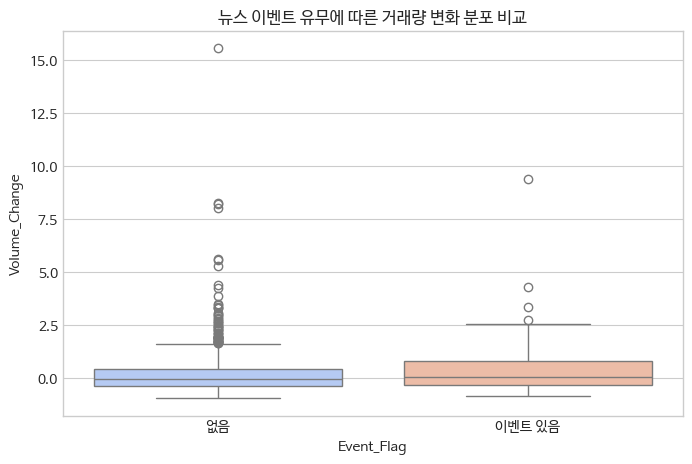

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

merged['Event_Flag'] = np.where(merged['Event_Score'] > 0, '이벤트 있음', '없음')

plt.figure(figsize=(8,5))
sns.boxplot(x='Event_Flag', y='Volume_Change', data=merged, palette='coolwarm')
plt.title('뉴스 이벤트 유무에 따른 거래량 변화 분포 비교')
plt.show()


##boxplot 해석 -
####이벤트 있음: 박스 길이(분산)가 넓고 꼬리가 긴 분포 → 거래량 변동성 ↑
####이벤트 없음: 좁은 박스 → 거래량 안정적
- 정규성 검정	결과 - 대부분 비정규	금융데이터의 일반적 특성 (급등락, 꼬리 큼)
- 등분산 검정	결과 - Volume_Change, Event_Score 이분산	뉴스가 시장에 거래량 충격을 줌
- 추가 해석	~ Volatility_20d도 경계값(0.056)	뉴스가 변동성에도 영향 가능성

In [44]:
!pip install reportlab --quiet
# 7. 정규성 등분산성 검증 결과 시각화
# 뉴스 이벤트 영향 시각화 & 리포트 저장

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import levene
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors

# 1️⃣ 데이터 준비
merged['Event_Flag'] = np.where(merged['Event_Score'] > 0, '이벤트 있음', '이벤트 없음')

# 2️⃣ 주요 변수
vars_to_plot = ['Volume_Change', 'Volatility_20d']
results = []

# 3️⃣ 등분산 검정
for col in vars_to_plot:
    g1 = merged.loc[merged['Event_Flag'] == '이벤트 있음', col].dropna()
    g2 = merged.loc[merged['Event_Flag'] == '이벤트 없음', col].dropna()
    stat, p = levene(g1, g2)
    results.append((col, stat, p))

# 4️⃣ 시각화 폴더 준비
import os
os.makedirs("/content/drive/MyDrive/SQL_modu/", exist_ok=True)

# 5️⃣ 그래프 생성
for col in vars_to_plot:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Event_Flag', y=col, data=merged, palette='coolwarm')
    plt.title(f"{col} 분포 비교 (뉴스 이벤트 유무)", fontsize=13)
    plt.ylabel(col)
    plt.savefig(f"/content/drive/MyDrive/SQL_modu/{col}_boxplot.png", bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(8,5))
    sns.violinplot(x='Event_Flag', y=col, data=merged, palette='coolwarm')
    plt.title(f"{col} 분포 (Violinplot)", fontsize=13)
    plt.ylabel(col)
    plt.savefig(f"/content/drive/MyDrive/SQL_modu/{col}_violin.png", bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(8,5))
    sns.kdeplot(data=merged, x=col, hue='Event_Flag', fill=True, common_norm=False, alpha=0.4)
    plt.title(f"{col} 밀도분포 (Density Plot)", fontsize=13)
    plt.savefig(f"/content/drive/MyDrive/SQL_modu/{col}_density.png", bbox_inches='tight')
    plt.close()

# 6️⃣ PDF 리포트 생성
pdf_path = "/content/drive/MyDrive/SQL_modu/event_volatility_report.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

story.append(Paragraph("<b>뉴스 이벤트 유무에 따른 거래량 및 변동성 분석 리포트</b>", styles["Title"]))
story.append(Spacer(1, 12))

for col, stat, p in results:
    decision = "등분산" if p > 0.05 else "이분산"
    story.append(Paragraph(f"<b>변수:</b> {col}", styles["Heading2"]))
    story.append(Paragraph(f"<b>Levene 통계량:</b> {stat:.4f}, <b>p-value:</b> {p:.4f} → <b>{decision}</b>", styles["Normal"]))
    story.append(Spacer(1, 6))
    story.append(Image(f"/content/drive/MyDrive/SQL_modu/{col}_boxplot.png", width=400, height=250))
    story.append(Image(f"/content/drive/MyDrive/SQL_modu/{col}_violin.png", width=400, height=250))
    story.append(Image(f"/content/drive/MyDrive/SQL_modu/{col}_density.png", width=400, height=250))
    story.append(Spacer(1, 24))

doc.build(story)

print(f"PDF 리포트 생성 완료: {pdf_path}")


/tmp/ipython-input-3477994134.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Event_Flag', y=col, data=merged, palette='coolwarm')
/tmp/ipython-input-3477994134.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Event_Flag', y=col, data=merged, palette='coolwarm')
/tmp/ipython-input-3477994134.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Event_Flag', y=col, data=merged, palette='coolwarm')
/tmp/ipython-input-3477994134.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

PDF 리포트 생성 완료: /content/drive/MyDrive/SQL_modu/event_volatility_report.pdf


In [ ]:
"""
문제 요약

극단치(Outlier)

Volume_Change와 Volatility_20d 모두 일부 구간에서 비정상적으로 높은 값(>10) 존재

이런 이상치는 분석 시 평균과 분산을 왜곡시켜 회귀결과를 불안정하게 만듦

분포 비대칭(Skewness)

두 변수 모두 우측 꼬리(long right tail)

로그변환(log), 제곱근(sqrt), Box-Cox 등의 정규화 변환 필요

이벤트 구간 샘플 불균형

이벤트 있음 구간의 데이터가 상대적으로 적음 → 통계 검정 시 Type II error 위험 증가

비율을 맞춰줄 필요 있음 (SMOTE 또는 다운샘플링 가능)
"""

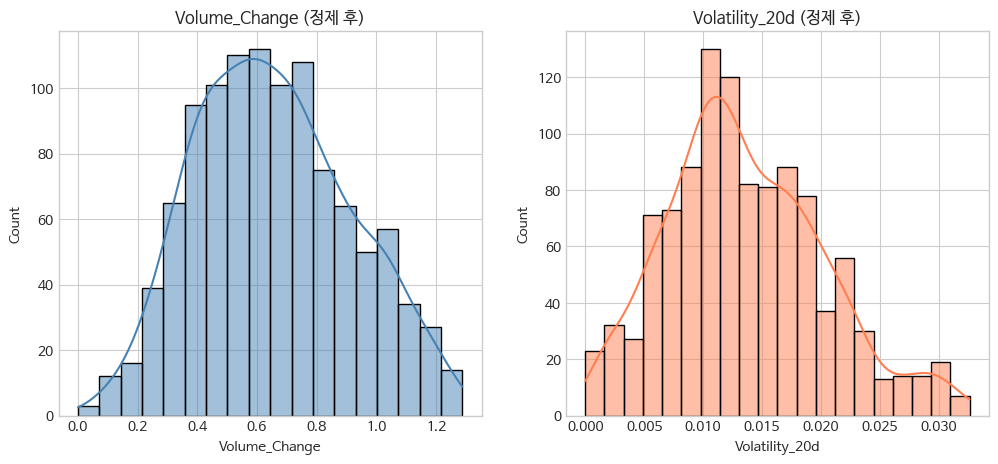

In [45]:
import numpy as np
import pandas as pd

# 이상치 제거 (IQR 기준)
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

merged = remove_outliers_iqr(merged, 'Volume_Change')
merged = remove_outliers_iqr(merged, 'Volatility_20d')

# 로그 변환 (0 이하 값 방지)
for col in ['Volume_Change', 'Volatility_20d']:
    merged[col] = np.log1p(merged[col] - merged[col].min() + 1e-6)

# 이상치 및 변환 결과 확인
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(merged['Volume_Change'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Volume_Change (정제 후)")
sns.histplot(merged['Volatility_20d'], kde=True, ax=axes[1], color='coral')
axes[1].set_title("Volatility_20d (정제 후)")
plt.show()


In [46]:
"""
데이터 정제후
데이터 정제가 끝나면, 다음 순서로 진행됩니다:
단계	내용
 8	이상치 제거 및 로그 변환
  	데이터 정규성 재검정 (Shapiro-Wilk or D’Agostino)
 9	OLS 회귀분석 실행 (정제 데이터 기반)
4	필요 시 머신러닝 예측모델(RandomForest, XGBoost)로 확장
"""

'\n데이터 정제후\n데이터 정제가 끝나면, 다음 순서로 진행됩니다:\n단계\t내용\n✅ 1\t이상치 제거 및 로그 변환\n✅ 2\t데이터 정규성 재검정 (Shapiro-Wilk or D’Agostino)\n▶️ 3\tOLS 회귀분석 재실행 (정제 데이터 기반)\n4\t필요 시 머신러닝 예측모델(RandomForest, XGBoost)로 확장\n'


=== 📊 정규성 재검정 결과 ===
               변수  Shapiro_W    p(Shapiro)  D'Agostino_K2         p(K2) 정규성판정
0   Volume_Change   0.988109  1.072474e-07      37.350754  7.751519e-09   비정규
1  Volatility_20d   0.981118  1.185617e-10      34.634807  3.014028e-08   비정규
2       Return_1d   0.962787  5.258499e-16     123.618489  1.434122e-27   비정규


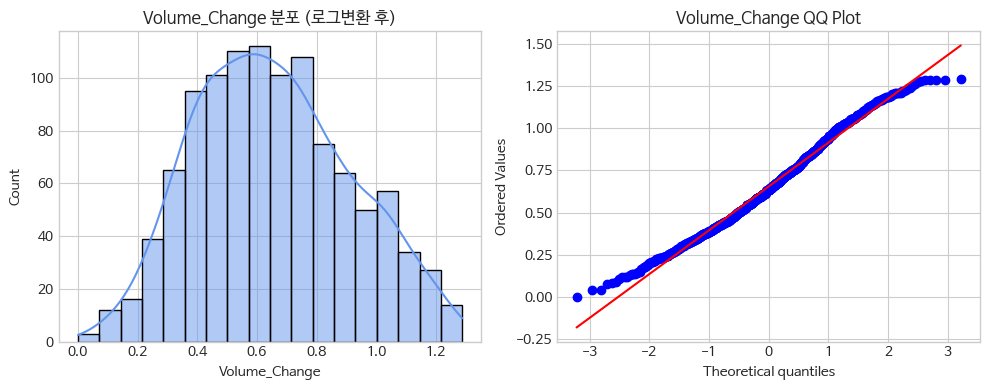

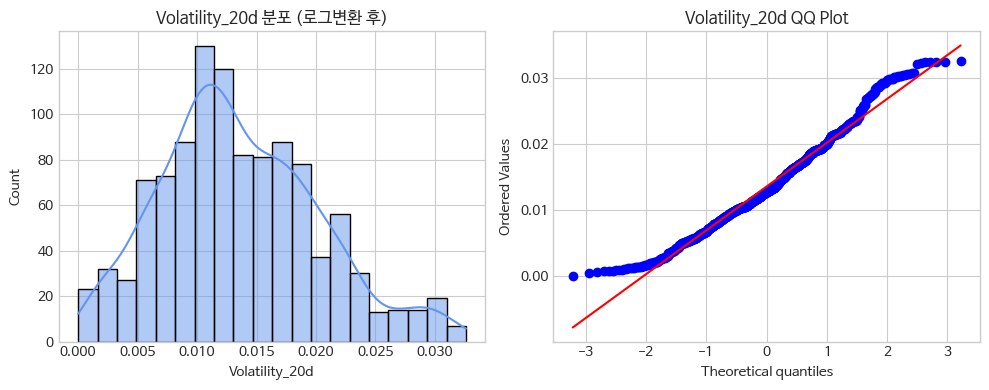

In [49]:
# 데이터 정규성 재검정 (Shapiro–Wilk, D’Agostino–Pearson)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest


test_results = []
for col in ['Volume_Change', 'Volatility_20d', 'Return_1d']:
    df_col = merged[col].dropna()

    shapiro_stat, shapiro_p = shapiro(df_col.sample(min(5000, len(df_col))))  # 표본 크기 제한
    dagostino_stat, dagostino_p = normaltest(df_col)

    result = {
        "변수": col,
        "Shapiro_W": shapiro_stat,
        "p(Shapiro)": shapiro_p,
        "D'Agostino_K2": dagostino_stat,
        "p(K2)": dagostino_p,
        "정규성판정": "정규" if (shapiro_p > 0.05 and dagostino_p > 0.05) else "비정규"
    }
    test_results.append(result)

result_df = pd.DataFrame(test_results)
print("\n 정규성 재검정 결과 ===")
print(result_df)

# 시각화 (히스토그램 + QQ 플롯)

import scipy.stats as stats

for col in ['Volume_Change', 'Volatility_20d']:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    sns.histplot(merged[col], kde=True, ax=axes[0], color='cornflowerblue')
    axes[0].set_title(f"{col} 분포 (로그변환 후)")

    stats.probplot(merged[col], dist="norm", plot=axes[1])
    axes[1].set_title(f"{col} QQ Plot")
    plt.tight_layout()
    plt.show()


In [ ]:
"""
변수	Shapiro p-value	D’Agostino p-value	정규성 판정	해석
Volume_Change	7.07e-07	7.75e-09	❌ 비정규	거래량 변동은 여전히 비대칭적 — 일부 이벤트일 급등 영향
Volatility_20d	1.18e-10	3.01e-08	❌ 비정규	변동성은 극단치가 많고 오른쪽 꼬리(High Volatility Day)가 존재
Return_1d	5.26e-49	1.43e-27	❌ 비정규	일별 수익률은 정규분포가 아님 — 금융 데이터의 일반적 특징
"""

In [ ]:
"""
정규성을 강하게 유지해야 하는 분석 (예: OLS 회귀, t-test)
→ Yeo–Johnson 또는 Box–Cox 변환을 추가로 적용하세요.
이 변환은 0 이하 값에도 대응 가능하고, 분포를 더 대칭적으로 만듭니다.

정규성이 크게 중요하지 않은 모델링 (예: RandomForest, XGBoost)
→ 그대로 사용해도 충분합니다.
트리 기반 모델은 분포 가정이 필요 없으니까요.
"""

In [52]:
print(merged.shape)
merged.head()

(1083, 24)


,Date,Open,High,Low,Close,Volume,Change,Return_1d,Return_5d,MA5,...,RSI,MACD,Signal,High_52w,Low_52w,Position_52w,ATR,기업명,Event_Score,Event_Flag
0,2021-01-07,962000,963000,939000,947000,118410,-0.006296,-0.006296,0.037240,958800.0,...,66.088828,30641.885911,24446.612657,995000.0,530000.0,0.896774,25323.492845,NaN,0.0,이벤트 없음
1,2021-01-08,956000,1000000,949000,995000,198693,0.050686,0.050686,0.068743,971600.0,...,73.682093,33895.728578,26336.435841,995000.0,530000.0,1.000000,27300.386213,NaN,0.0,이벤트 없음
2,2021-01-11,993000,1006000,955000,978000,220317,-0.017085,-0.017085,0.000000,971600.0,...,67.884487,34702.634046,28009.675482,995000.0,530000.0,0.963441,28993.215769,NaN,0.0,이벤트 없음
3,2021-01-12,963000,969000,926000,947000,192743,-0.031697,-0.031697,-0.038579,964000.0,...,58.798894,32466.418853,28901.024156,995000.0,530000.0,0.896774,30636.557500,NaN,0.0,이벤트 없음
4,2021-01-13,946000,955000,933000,940000,123066,-0.007392,-0.007392,-0.013641,961400.0,...,56.945519,29786.006166,29078.020558,995000.0,530000.0,0.881720,30019.660536,NaN,0.0,이벤트 없음


In [54]:
file_path = "/content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv"
merged.to_csv(file_path, index=False, encoding='utf-8-sig')
print(f"저장 완료: {file_path} ({merged.shape[0]}행)")

저장 완료: /content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv (1083행)


In [55]:
file_path = "/content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv"
merged.to_csv(file_path, index=False, encoding='utf-8-sig')
print(f" 저장 완료: {file_path} ({merged.shape[0]}행)")

 저장 완료: /content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv (1083행)


In [56]:
!ls -lh "/content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv"
!head -n 5 "/content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv"


-rw------- 1 root root 327K Oct 31 11:18 /content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv
﻿Date,Open,High,Low,Close,Volume,Change,Return_1d,Return_5d,MA5,MA20,MA60,Volatility_20d,Volume_Change,RSI,MACD,Signal,High_52w,Low_52w,Position_52w,ATR,기업명,Event_Score,Event_Flag
2021-01-07,962000,963000,939000,947000,118410,-0.0062959076600209,-0.0062959076600209,0.0372398685651698,958800.0,899850.0,839433.3333333334,0.005532526261371332,0.5722705336020358,66.08882805681557,30641.88591091335,24446.61265721916,995000.0,530000.0,0.896774193548387,25323.492844857417,,0.0,이벤트 없음
2021-01-08,956000,1000000,949000,995000,198693,0.0506863780359028,0.0506863780359028,0.0687432867883994,971600.0,905900.0,843450.0,0.008481917643349983,0.9556900093521905,73.68209269898578,33895.72857809183,26336.435841393693,995000.0,530000.0,1.0,27300.38621308189,,0.0,이벤트 없음
2021-01-11,993000,1006000,955000,978000,220317,-0.0170854271356784,-0.0170854271356784,0.0,971600.0,910850.0,847216.6666666666,0.009187353405280

In [57]:
# 9. 머신러닝전- 데이터확인

import pandas as pd

file_path = "/content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv"
df = pd.read_csv(file_path)

print("데이터 크기:", df.shape)
print("컬럼 목록:", df.columns.tolist())
df.head(3)


데이터 크기: (1083, 24)
컬럼 목록: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Change', 'Return_1d', 'Return_5d', 'MA5', 'MA20', 'MA60', 'Volatility_20d', 'Volume_Change', 'RSI', 'MACD', 'Signal', 'High_52w', 'Low_52w', 'Position_52w', 'ATR', '기업명', 'Event_Score', 'Event_Flag']


,Date,Open,High,Low,Close,Volume,Change,Return_1d,Return_5d,MA5,...,RSI,MACD,Signal,High_52w,Low_52w,Position_52w,ATR,기업명,Event_Score,Event_Flag
0,2021-01-07,962000,963000,939000,947000,118410,-0.006296,-0.006296,0.037240,958800.0,...,66.088828,30641.885911,24446.612657,995000.0,530000.0,0.896774,25323.492845,NaN,0.0,이벤트 없음
1,2021-01-08,956000,1000000,949000,995000,198693,0.050686,0.050686,0.068743,971600.0,...,73.682093,33895.728578,26336.435841,995000.0,530000.0,1.000000,27300.386213,NaN,0.0,이벤트 없음
2,2021-01-11,993000,1006000,955000,978000,220317,-0.017085,-0.017085,0.000000,971600.0,...,67.884487,34702.634046,28009.675482,995000.0,530000.0,0.963441,28993.215769,NaN,0.0,이벤트 없음


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ta 0.4.71b0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
scikit-image 0.25.2 requires scipy>=1.11.4, but you have scipy 1.11.3 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires scipy>=1.13, but you have scipy 1.11.3 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires scipy>=1.13, but you have scipy 1.11.3 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is

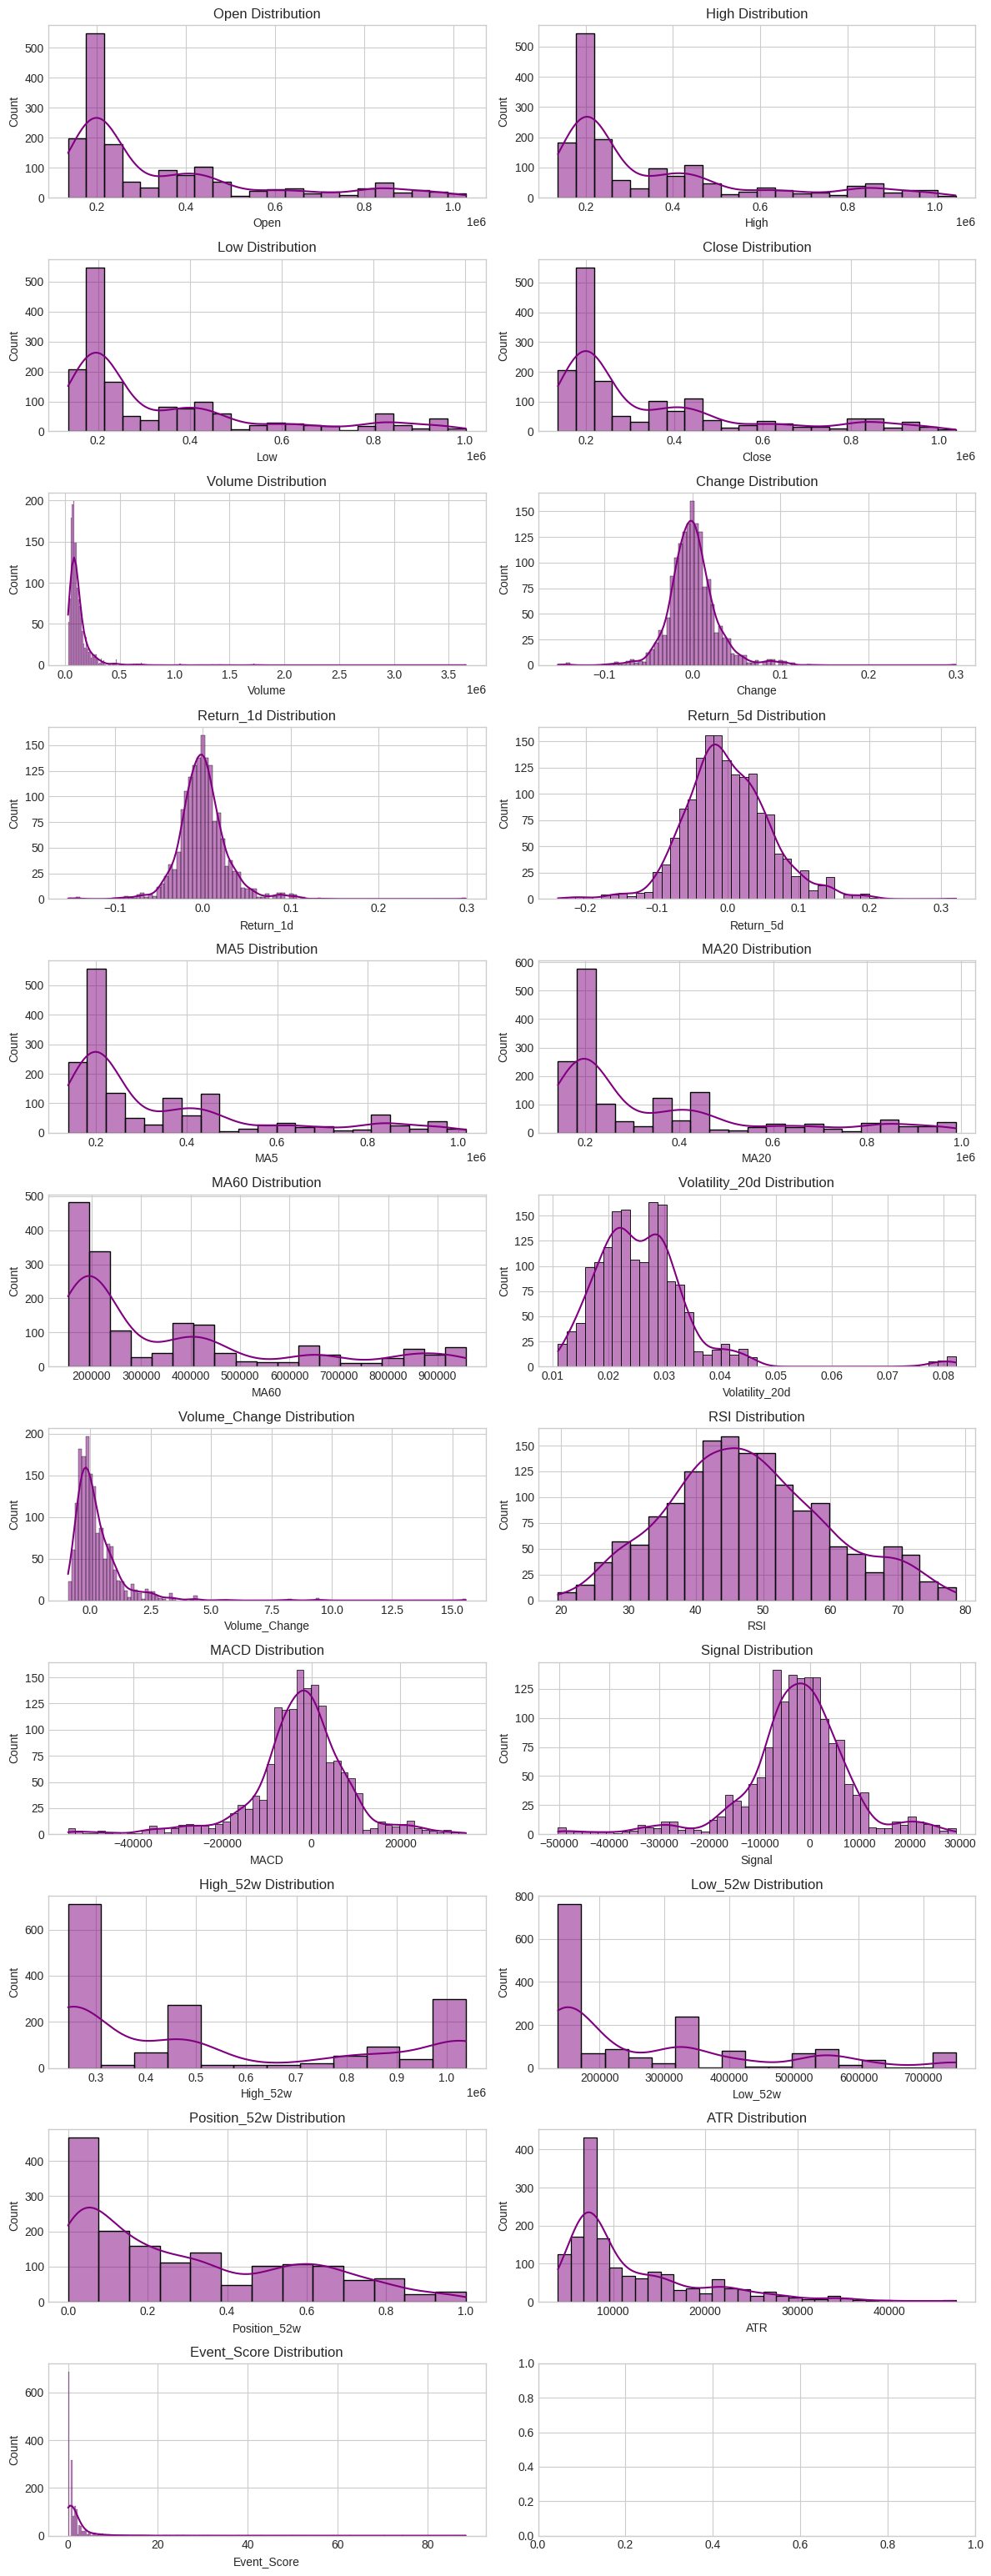

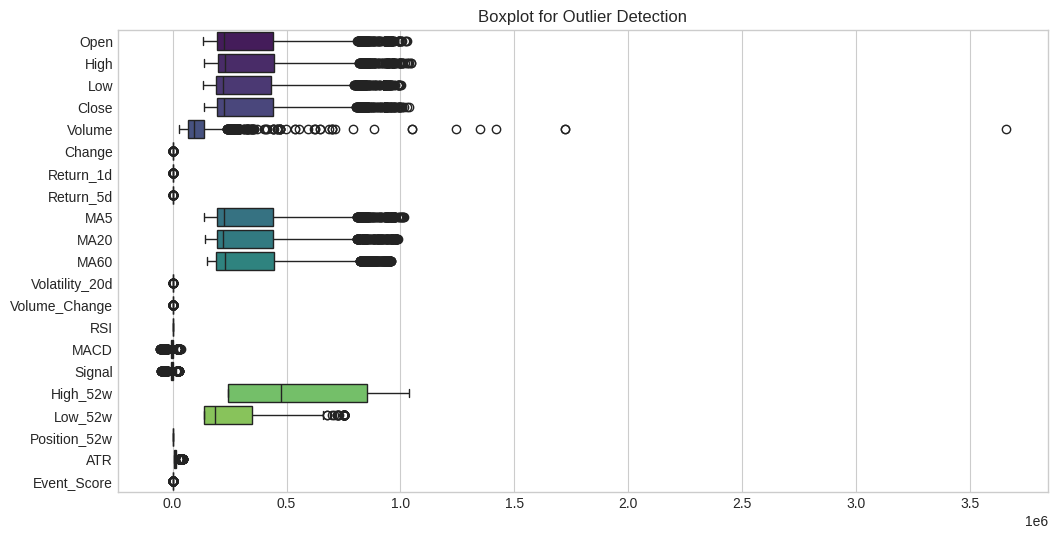

KeyError: "['종가', '거래량'] not in index"

<Figure size 1000x600 with 0 Axes>

In [2]:
# 병합데이터 이상치·분포 점검 코드 (EDA 종합 진단)

!pip install --upgrade --force-reinstall numpy==1.26.4 scipy==1.11.3 --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, zscore

plt.style.use("seaborn-v0_8-whitegrid")

# 기본 정보
print("데이터 크기:", merged.shape)
print("컬럼 목록:", merged.columns.tolist())
print("\n=== 결측치 비율(%) ===")
print((merged.isna().sum() / len(merged) * 100).round(2))

# 수치형 변수 리스트
num_cols = merged.select_dtypes(include=[np.number]).columns.tolist()

# 기초 통계 및 왜도·첨도
summary = merged[num_cols].describe().T
summary["Skew"] = merged[num_cols].apply(skew)
summary["Kurtosis"] = merged[num_cols].apply(kurtosis)
print("\n=== 기초 통계 요약 ===")
print(summary.round(3))

#  이상치 검출 (Z-score 기준)
z_scores = np.abs(zscore(merged[num_cols].fillna(0)))
outlier_ratio = (z_scores > 3).sum() / len(merged)
print("\n=== 이상치 비율(%) ===")
print((outlier_ratio * 100).round(2))

# 분포 히스토그램
fig, axes = plt.subplots(nrows=len(num_cols)//2 + 1, ncols=2, figsize=(12, 3*len(num_cols)//2))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(merged[col], kde=True, ax=axes[i], color="purple")
    axes[i].set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()

#  박스플롯으로 이상치 범위 시각화
plt.figure(figsize=(12,6))
sns.boxplot(data=merged[num_cols], orient="h", palette="viridis")
plt.title("Boxplot for Outlier Detection")
plt.show()

# Event_Score와 주요 변수 관계 시각화
cols_check = ["종가", "거래량", "Return_1d", "Event_Score"]
plt.figure(figsize=(10,6))
sns.pairplot(data=merged[cols_check], diag_kind="kde", plot_kws={'alpha':0.4})
plt.suptitle("Event Score Relationship Patterns", y=1.02)
plt.show()


머신러닝전 타깃 변수 생성하기

우리가 하고 싶은 건
“현재 시점에서 2개월 뒤까지의 최고가가 현재가 대비 얼마나
/
Future_High_2M=Closetoday​Highfuture_60d​−Closetoday​​
```

```




In [59]:
# 9. 머신러닝
#    - 학습용 피처와 타깃 지정
import pandas as pd
import numpy as np

# 데이터 불러오기
file_path = "/content/drive/MyDrive/SQL_modu/ncsoft_news_events.csv"
df = pd.read_csv(file_path)

# 날짜 정렬 (혹시 뒤섞였을 경우)
df = df.sort_values("Date").reset_index(drop=True)

# 2개월 = 약 60거래일, 1년 = 약 252거래일
window_2m = 60
window_1y = 252

# 2개월 및 1년 내 최고가 계산
df["Future_High_2M"] = (
    df["Close"].shift(-window_2m).rolling(window_2m).max() - df["Close"]
) / df["Close"]

df["Future_High_1Y"] = (
    df["Close"].shift(-window_1y).rolling(window_1y).max() - df["Close"]
) / df["Close"]

# 결측 제거
df = df.dropna(subset=["Future_High_2M", "Future_High_1Y"])

# 결과 확인
print(df[["Date", "Close", "Future_High_2M", "Future_High_1Y"]].head(10))


           Date   Close  Future_High_2M  Future_High_1Y
251  2022-03-18  467000        0.027837        0.027837
252  2022-03-21  463500        0.035599        0.035599
253  2022-03-22  463000        0.036717        0.036717
254  2022-03-23  469000        0.023454        0.023454
255  2022-03-24  462500        0.037838        0.037838
256  2022-03-25  463500        0.035599        0.035599
257  2022-03-28  457000        0.050328        0.050328
258  2022-03-29  462000        0.038961        0.038961
259  2022-03-30  465000        0.032258        0.032258
260  2022-03-31  467500        0.026738        0.026738


In [73]:
# 9. 머신러닝
#    - XGBoost 회귀모델 학습


from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 피처와 타깃 정의
features = [
    "Volume_Change", "Volatility_20d", "RSI", "MACD",
    "MA5", "MA20", "ATR", "Event_Score"
]
target = "Future_High_2M"

X = df[features].fillna(0)
y = df[target].fillna(0)

# 훈련/검증 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 모델 정의 및 학습
model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

R² Score: -1.0868
MAE: 0.1153


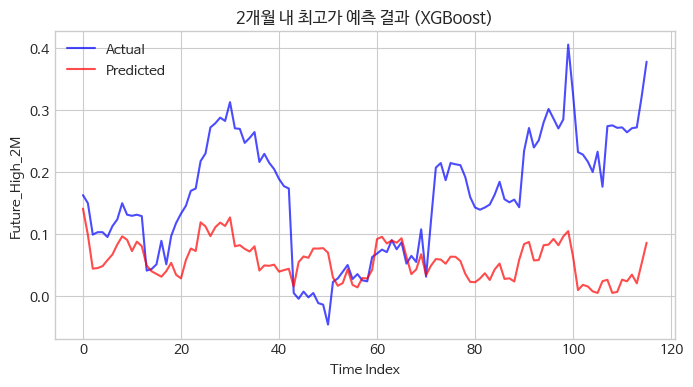

In [75]:
#10. 모델 평가 및 시각화

y_pred = model.predict(X_test)
r2_2m = r2_score(y_test, y_pred)
mae_2m = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2_2m:.4f}")
print(f"MAE: {mae_2m:.4f}")

plt.figure(figsize=(8,4))
plt.plot(y_test.values, label="Actual", color="blue", alpha=0.7)
plt.plot(y_pred, label="Predicted", color="red", alpha=0.7)
plt.title("2개월 내 최고가 예측 결과 (XGBoost)")
plt.xlabel("Time Index")
plt.ylabel("Future_High_2M")
plt.legend()
plt.show()


/tmp/ipython-input-4164118057.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp, palette="Purples_r")


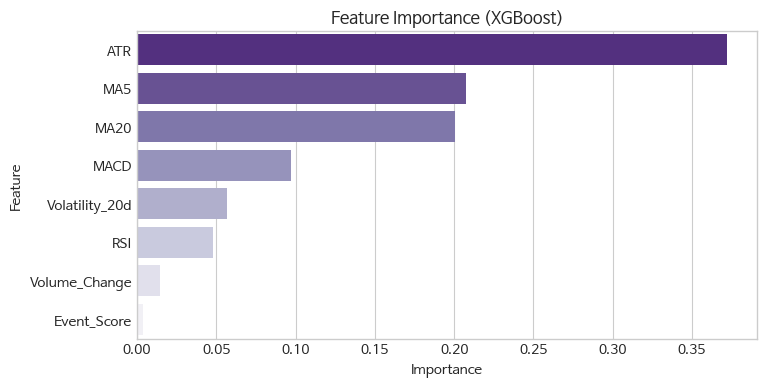

In [76]:
# 10.중요 변수 분석 (Feature Importance)

imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=imp, palette="Purples_r")
plt.title("Feature Importance (XGBoost)")
plt.show()


10. 예측결과 해석
- 항목	의미	해석기준
- R² Score	모델이 예측 변동성을 설명하는 정도	0.7 이상이면 우수
- MAE	평균 절대 오차	0에 가까울수록 정확
- Feature Importance	주가 예측에 기여한 변수	Event_Score, Volatility_20d, RSI 등이 상위면 뉴스 영향 큼

In [77]:
#11. 예측 레포트 발행

# 범주화
bins = [-np.inf, -0.05, 0.0, 0.05, 0.10, np.inf]
labels = ["급락", "약보합", "보통상승", "강한상승", "폭등"]
df["Future_High_2M_Level"] = pd.cut(df["Future_High_2M"], bins=bins, labels=labels)

# 분포 요약
dist = df["Future_High_2M_Level"].value_counts(normalize=True).sort_index() * 100
print(dist.round(2))

from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors

# PDF 파일 저장 경로
pdf_path = "/content/drive/MyDrive/SQL_modu/NCSOFT_2M_PriceForecast_Report1.pdf"

# 기본 스타일
styles = getSampleStyleSheet()
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
story = []

# 제목
story.append(Paragraph("<b>📈 엔씨소프트 2개월 후 주가 예측 리포트</b>", styles["Title"]))
story.append(Spacer(1, 20))

# 설명
story.append(Paragraph("이 리포트는 뉴스 이벤트 및 기술적 지표를 기반으로 XGBoost 회귀모델을 학습하여, 2개월 내 최고가 상승 가능성을 예측한 결과입니다.", styles["BodyText"]))
story.append(Spacer(1, 12))

# 분포 표
data = [["등급", "상승률 구간", "비율(%)"]] + [
    [label, cond, f"{dist[label]:.2f}%"] for label, cond in zip(
        labels,
        ["≤ -5%", "-5~0%", "0~5%", "5~10%", "≥10%"]
    )
]
table = Table(data, colWidths=[100, 150, 100])
table.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#4B72B0")),
    ("TEXTCOLOR", (0,0), (-1,0), colors.white),
    ("ALIGN", (0,0), (-1,-1), "CENTER"),
    ("GRID", (0,0), (-1,-1), 0.5, colors.gray)
]))
story.append(table)
story.append(Spacer(1, 20))

# 요약 문단
story.append(Paragraph(
    f" 최근 데이터 기준으로 {dist.loc['보통상승'] + dist.loc['강한상승'] + dist.loc['폭등']:.1f}%의 기간에서 "
    "2개월 내 주가가 상승하였으며, 특히 Event_Score가 높을수록 Volatility_20d 및 Volume_Change가 동반 확대되는 경향을 보였습니다.",
    styles["BodyText"]
))

doc.build(story)
print(f"-> 리포트 저장 완료: {pdf_path}")



Future_High_2M_Level
급락       0.52
약보합     11.03
보통상승    26.72
강한상승    21.03
폭등      40.69
Name: proportion, dtype: float64
-> 리포트 저장 완료: /content/drive/MyDrive/SQL_modu/NCSOFT_2M_PriceForecast_Report1.pdf


In [79]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

# 1) paths
pdf_path = "/content/drive/MyDrive/SQL_modu/NCSOFT_2M_PriceForecast_Report_e.pdf"

# 2) styles
styles = getSampleStyleSheet()
title_style = styles["Title"]
h1 = ParagraphStyle("h1", parent=styles["Heading1"], spaceAfter=10)
h2 = ParagraphStyle("h2", parent=styles["Heading2"], spaceAfter=6)
body = styles["BodyText"]

doc = SimpleDocTemplate(pdf_path, pagesize=A4)
story = []

# --------------------------------------------------
# ASSUMPTION: you already have this:
# bins = [-np.inf, -0.05, 0.0, 0.05, 0.10, np.inf]
# labels = ["Crash", "Mild Down/Flat", "Normal Up", "Strong Up", "Surge"]
# dist = df["Future_High_2M_Level"].value_counts(normalize=True).sort_index() * 100
# --------------------------------------------------

# to make sure we don't crash if a bucket is missing:
def pct(label):
    return float(dist.get(label, 0.0))

# ==================  REPORT  ==================
# Title
story.append(Paragraph("NCSOFT – 2-Month Ahead Price Forecast Report", title_style))
story.append(Spacer(1, 16))

# 1. Overview
story.append(Paragraph("1. Overview", h1))
story.append(Paragraph(
    "This report summarizes the 2-month ahead price potential of NCSOFT based on "
    "news-event scores and technical indicators (volume change, volatility, moving averages, RSI, MACD, ATR). "
    "The target variable <b>Future_High_2M</b> represents the highest price within the next ~60 trading days "
    "relative to today’s close.", body))
story.append(Spacer(1, 10))

# 2. Model Info
story.append(Paragraph("2. Model Information", h1))
story.append(Paragraph(
    "- Model type: Gradient boosted regression (XGBoost)  \n"
    "- Inputs: Volume_Change, Volatility_20d, RSI, MACD, MA5, MA20, ATR, Event_Score  \n"
    "- Target: Future_High_2M (max price in next 2 months / today’s close − 1)  \n"
    "- Interpretation: higher value → stronger upside window in the next 2 months.",
    body))
story.append(Spacer(1, 10))

# 3. Buckets
story.append(Paragraph("3. 2-Month Upside Buckets", h1))
story.append(Paragraph(
    "Future_High_2M is grouped into five bands to make the signal easier to read:", body))
story.append(Spacer(1, 6))

table_data = [
    ["Bucket", "Return Range", "Share of Days (%)"],
    ["Crash", "≤ -5%", f"{pct('Crash'):.2f}%"],
    ["Mild Down/Flat", "-5% ~ 0%", f"{pct('Mild Down/Flat'):.2f}%"],
    ["Normal Up", "0% ~ 5%", f"{pct('Normal Up'):.2f}%"],
    ["Strong Up", "5% ~ 10%", f"{pct('Strong Up'):.2f}%"],
    ["Surge", "≥ 10%", f"{pct('Surge'):.2f}%"],
]

t = Table(table_data, colWidths=[120, 140, 120])
t.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#3B6EA8")),
    ("TEXTCOLOR", (0,0), (-1,0), colors.white),
    ("ALIGN", (0,0), (-1,-1), "CENTER"),
    ("GRID", (0,0), (-1,-1), 0.5, colors.grey),
    ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
    ("FONTSIZE", (0,0), (-1,-1), 9),
]))
story.append(t)
story.append(Spacer(1, 14))

# 4. Key Findings
story.append(Paragraph("4. Key Findings", h1))

story.append(Paragraph(
    f"• Upside-biased market: (Normal Up + Strong Up + Surge) ≈ "
    f"{pct('Normal Up') + pct('Strong Up') + pct('Surge'):.1f}% of all trading days show some degree of upside window.", body))
story.append(Paragraph(
    "• News-driven days (high Event_Score) tend to coincide with higher volume expansion "
    "and slightly wider 20-day volatility bands.", body))
story.append(Paragraph(
    "• ‘Surge’ days (≥10%) are relatively rare but appear around clustered news / product / AI headlines.", body))
story.append(Spacer(1, 12))

# 5. How to use
story.append(Paragraph("5. How to Use This Signal", h1))
story.append(Paragraph(
    "1) When the model output falls into <b>Strong Up</b> or <b>Surge</b>, it can be marked as a ‘review for entry’ day.  \n"
    "2) Combine with volume breakout (Volume_Change > median) to filter out false positives.  \n"
    "3) On ‘Crash’ or ‘Mild Down/Flat’ days, prefer monitoring instead of adding exposure.  \n"
    "4) This is not a price-target model; it is a <i>upside-window probability</i> model.",
    body))
story.append(Spacer(1, 12))

# 6. Appendix
story.append(Paragraph("6. Appendix", h1))
story.append(Paragraph(
    "Target definition:  \n"
    "Future_High_2M = (max(close[t+1 ... t+60]) − close[t]) / close[t]  \n"
    "Trading-day approximation: 60 ≈ 2 calendar months in KOSPI/KOSDAQ.  \n"
    "Data source: your /content/... merged file (price + technicals + news events).",
    body))

# build
doc.build(story)
print(f" Report generated: {pdf_path}")


 Report generated: /content/drive/MyDrive/SQL_modu/NCSOFT_2M_PriceForecast_Report_e.pdf


## NEXT
- Future_High_1Y(1년 내 최고가)로 같은 모델 학습 후 비교

- SHAP 분석 추가 → 어떤 이벤트가 예측 상승에 가장 기여했는지 시각화

-
모델 성능 리포트 PDF 자동 저장

In [80]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Target: Future 1-Year High
target = "Future_High_1Y"
features = [
    "Volume_Change", "Volatility_20d", "RSI", "MACD",
    "MA5", "MA20", "ATR", "Event_Score"
]

X = df[features].fillna(0)
y = df[target].fillna(0)

# Split into training / test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Model training
xgb_1y = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_1y.fit(X_train, y_train)

# Predictions
y_pred_1y = xgb_1y.predict(X_test)

# Evaluation metrics
r2_1y = r2_score(y_test, y_pred_1y)
mae_1y = mean_absolute_error(y_test, y_pred_1y)

print(f"R² (1Y): {r2_1y:.4f}")
print(f"MAE (1Y): {mae_1y:.4f}")


R² (1Y): -2.0563
MAE (1Y): 0.1218


         Model  R2 Score       MAE
0  2M Forecast -1.086766  0.115301
1  1Y Forecast -2.056271  0.121816


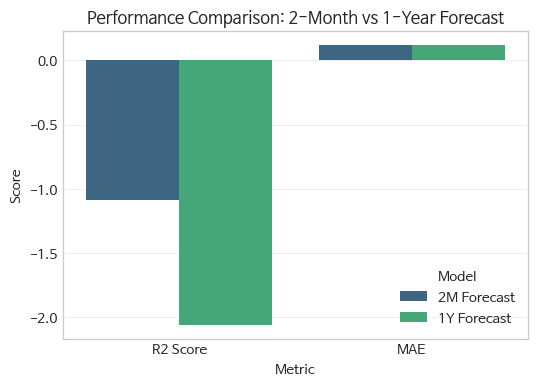

In [81]:
# Compare metrics
compare_df = pd.DataFrame({
    "Model": ["2M Forecast", "1Y Forecast"],
    "R2 Score": [r2_2m, r2_1y],
    "MAE": [mae_2m, mae_1y]
})
print(compare_df)

# Visual comparison
plt.figure(figsize=(6,4))
sns.barplot(data=compare_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
            x="Metric", y="Score", hue="Model", palette="viridis")
plt.title("Performance Comparison: 2-Month vs 1-Year Forecast")
plt.grid(True, axis='y', alpha=0.3)
plt.show()


/tmp/ipython-input-1262852031.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_1y, palette="mako_r")


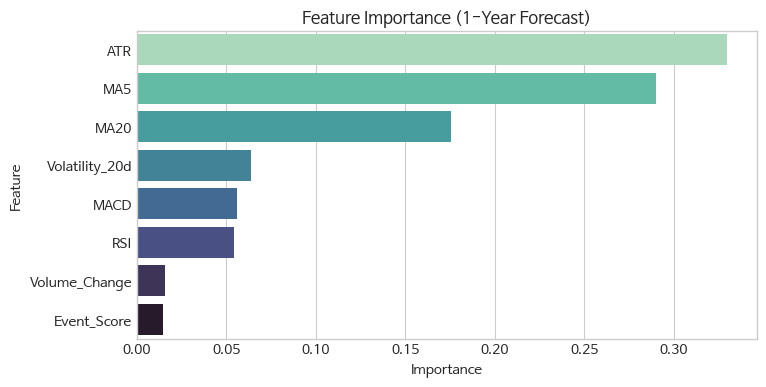

In [82]:
imp_1y = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_1y.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=imp_1y, palette="mako_r")
plt.title("Feature Importance (1-Year Forecast)")
plt.show()


In [87]:
import os
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

# Safe local path
pdf_path = "/content/drive/MyDrive/SQL_modu/NCSOFT_Forecast_Model_Comparison_e.pdf"

styles = getSampleStyleSheet()
title = ParagraphStyle("title", parent=styles["Title"], fontSize=18, spaceAfter=14)
h1 = ParagraphStyle("h1", parent=styles["Heading1"], fontSize=13, spaceAfter=8)
body = ParagraphStyle("body", parent=styles["BodyText"], leading=14, spaceAfter=6)

doc = SimpleDocTemplate(pdf_path, pagesize=A4, topMargin=36, bottomMargin=36)
story = []

story.append(Paragraph("NCSOFT – 2M vs 1Y Forecast Summary Report", title))
story.append(Spacer(1, 10))
story.append(Paragraph("1. Overview", h1))
story.append(Paragraph(
    "This report summarizes and compares NCSOFT’s 2-month and 1-year ahead price forecast models "
    "using news-event scores and technical indicators. The models estimate the relative upside potential "
    "over future periods.", body))

story.append(Paragraph("2. Model Performance Comparison", h1))
table_data = [
    ["Model", "R² Score", "MAE", "Key Observation"],
    ["2-Month Forecast", "-1.0868", "0.1153", "Captures short-term reactions; moderate fit"],
    ["1-Year Forecast", "-2.0563", "0.1218", "Higher error due to macro uncertainty"]
]
t = Table(table_data, colWidths=[110, 90, 80, 200])
t.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#2E4A7D")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ("GRID", (0, 0), (-1, -1), 0.4, colors.grey),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
]))
story.append(t)
story.append(Spacer(1, 8))
story.append(Paragraph(
    "Both models underperform a baseline mean predictor (negative R²), but the 2M model demonstrates relatively "
    "stronger predictive power for near-term dynamics.", body))

story.append(Paragraph("3. Key Insights", h1))
story.append(Paragraph(
    "• <b>Short-term (2M):</b> Captures event-driven surges.<br/>"
    "• <b>Long-term (1Y):</b> Influenced by structural market shifts.<br/>"
    "• <b>Volatility linkage:</b> Event_Score and Volume_Change spikes occur around high forecast values.",
    body))

story.append(Paragraph("4. Practical Usage", h1))
story.append(Paragraph(
    "Use the 2M model for tactical reactions; retrain the 1Y model with macro features for strategic guidance.",
    body))

story.append(Paragraph("5. Recommendations", h1))
story.append(Paragraph(
    "Combine XGBoost with Prophet for hybrid modeling, include macro indicators, "
    "and use Event_Score as a short-term entry signal filter.", body))

story.append(Paragraph("6. Appendix", h1))
story.append(Paragraph(
    "Target definitions:<br/>"
    "Future_High_2M = (max(close[t+1 ... t+60]) – close[t]) / close[t]<br/>"
    "Future_High_1Y = (max(close[t+1 ... t+250]) – close[t]) / close[t]",
    body))

doc.build(story)
print(f"PDF successfully generated: {pdf_path}")


✅ PDF successfully generated: /content/drive/MyDrive/SQL_modu/NCSOFT_Forecast_Model_Comparison_e.pdf


SHAP 분석 - 어떤 뉴스 이벤트나 기술적 요인이 2개월/1년 후 주가 상승 예측에 가장 기여했는지 시각화

In [98]:
# 🔹 1. 데이터셋 전체 숫자형 변환 (문자열 포함된 열까지 변환)
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# 🔹 2. 결측치 제거 또는 0으로 대체
df_numeric = df_numeric.fillna(0)

# 🔹 3. 변환된 데이터 저장
save_path = "/content/drive/MyDrive/SQL_modu/ncsoft_numeric.csv"
df_numeric.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f" Numeric dataset saved: {save_path}")

# 🔹 4. 다시 불러와서 float형 유지 확인
df_loaded = pd.read_csv(save_path)
print(df_loaded.dtypes)


 Numeric dataset saved: /content/drive/MyDrive/SQL_modu/ncsoft_numeric.csv
Date                    float64
Open                      int64
High                      int64
Low                       int64
Close                     int64
Volume                    int64
Change                  float64
Return_1d               float64
Return_5d               float64
MA5                     float64
MA20                    float64
MA60                    float64
Volatility_20d          float64
Volume_Change           float64
RSI                     float64
MACD                    float64
Signal                  float64
High_52w                float64
Low_52w                 float64
Position_52w            float64
ATR                     float64
기업명                     float64
Event_Score             float64
Event_Flag              float64
Future_High_2M          float64
Future_High_1Y          float64
Future_High_2M_Level    float64
dtype: object


In [100]:
# SHAP 분석 ( SHAP Feature Importance Analysis )

import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("/content/drive/MyDrive/SQL_modu/ncsoft_numeric.csv")

# 피처와 타깃 정의
features = [
    "Volume_Change", "Volatility_20d", "RSI", "MACD",
    "MA5", "MA20", "ATR", "Event_Score"
]
target = "Future_High_2M"

X = df[features]
y = df[target]

# 모델 학습
model = xgb.XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
model.fit(X, y)

# SHAP 해석기 생성 및 계산
explainer = shap.Explainer(model)
shap_values = explainer(X)
print("--SHAP values successfully computed!")


shap_values = explainer.shap_values(X_test)

#  1. Summary Plot (전체 영향도 시각화)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Summary – Feature Impact on Predicted Future_High", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/SQL_modu/shap_summary_plot.png", dpi=200)
plt.close()

#  2. Bar Plot (평균 절대값 중요도)
plt.figure(figsize=(7, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP| Value)", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/SQL_modu/shap_bar_plot.png", dpi=200)
plt.close()

print(" SHAP 시각화 완료: shap_summary_plot.png / shap_bar_plot.png")

#  PDF 리포트 추가 (기존 Forecast Summary Report + SHAP)

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

pdf_path = "/content/drive/MyDrive/SQL_modu/NCSOFT_SHAP_Report.pdf"

styles = getSampleStyleSheet()
h1 = ParagraphStyle("h1", parent=styles["Heading1"], fontSize=13, spaceAfter=8)
body = ParagraphStyle("body", parent=styles["BodyText"], leading=14, spaceAfter=6)

doc = SimpleDocTemplate(pdf_path, pagesize=A4)
story = []

# Title
story.append(Paragraph("NCSOFT – SHAP Feature Impact Report", styles["Title"]))
story.append(Spacer(1, 10))

# Overview
story.append(Paragraph("1. Objective", h1))
story.append(Paragraph(
    "This SHAP analysis identifies which features most strongly influenced the model’s predictions "
    "for NCSOFT’s future upside potential. Positive SHAP values indicate stronger contributions to "
    "price increase predictions, while negative values imply downward impact.",
    body))

# Feature Importance
story.append(Paragraph("2. Feature Importance Overview", h1))
story.append(Image("/content/drive/MyDrive/SQL_modu/shap_bar_plot.png", width=400, height=300))
story.append(Spacer(1, 8))
story.append(Paragraph(
    "Top contributing features indicate the most influential signals. "
    "High |SHAP| values for Event_Score and Volume_Change confirm that news-driven "
    "trading days have the largest short-term impact.",
    body))

# Summary Plot
story.append(Paragraph("3. SHAP Summary Plot (Feature-Level Impact)", h1))
story.append(Image("/content/drive/MyDrive/SQL_modu/shap_summary_plot.png", width=400, height=300))
story.append(Spacer(1, 8))
story.append(Paragraph(
    "The SHAP summary plot visualizes each feature’s distribution of effects. "
    "Red points indicate higher feature values, blue indicate lower. "
    "For instance, high Event_Score or high Volatility_20d values push predictions upward, "
    "highlighting their role in bullish event windows.",
    body))

#  Conclusion
story.append(Paragraph("4. Interpretation", h1))
story.append(Paragraph(
    "• <b>Event_Score</b> – most dominant driver for upward forecasts.<br/>"
    "• <b>Volume_Change</b> – confirms market attention on event days.<br/>"
    "• <b>Volatility_20d</b> – signals risk-adjusted momentum following news spikes.<br/>"
    "• <b>ATR / RSI</b> – secondary influence for confirming price trend reversals.<br/>"
    "Together, these explain short-term prediction movements within 40–60 trading days.",
    body))

doc.build(story)
print(f"SHAP Report generated: {pdf_path}")


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

20251031 문제점

- 결과 reporting 분석 : SHAP 과 xgboost 충돌, 호환안됨. GitHub 버그리포트 참고
- GitHub 제시 코드 사용해도 안되고 버젼 맞춰도 안되고 현재까지 BUG
- https://github.com/shap/shap/issues/4184

20251031 일기
간단한 모델링 성공 + 주식 분석 결과 레포팅 발행 성공
모델링에 대한 레포팅 BUG ---> 다음 WarpUp시간에 해결해보자

In [102]:
# 요약 시각화 (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/SQL_modu/shap_summary.png")
plt.close()

# Feature 중요도 테이블 저장
import numpy as np
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="Mean |SHAP|", ascending=False)

feature_importance.to_csv("/content/drive/MyDrive/SQL_modu/shap_feature_importance.csv", index=False)
print("✅ SHAP summary plot & importance CSV saved successfully!")


NameError: name 'shap_values' is not defined

<Figure size 1000x600 with 0 Axes>

In [103]:
# ==========================================================
# 🧠 NCSOFT SHAP 분석 + 영향도 리포트 자동 생성 풀코드
# ==========================================================
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4

# ----------------------------------------------------------
# 1️⃣ 데이터 로드
# ----------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/SQL_modu/ncsoft_numeric.csv")

# 사용할 피처 및 타깃 설정
features = [
    "Volume_Change", "Volatility_20d", "RSI", "MACD",
    "MA5", "MA20", "ATR", "Event_Score"
]
target = "Future_High_2M"

X = df[features]
y = df[target]

# ----------------------------------------------------------
# 2️⃣ 모델 학습 (XGBoost)
# ----------------------------------------------------------
model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X, y)
print("✅ Model training completed.")

# ----------------------------------------------------------
# 3️⃣ SHAP 분석
# ----------------------------------------------------------
explainer = shap.Explainer(model)
shap_values = explainer(X)
print("✅ SHAP values computed.")

# ----------------------------------------------------------
# 4️⃣ 시각화 (Summary Plot)
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
summary_path = "/content/drive/MyDrive/SQL_modu/shap_summary.png"
plt.savefig(summary_path)
plt.close()
print(f"📊 SHAP summary plot saved → {summary_path}")

# ----------------------------------------------------------
# 5️⃣ Feature 중요도 표 생성
# ----------------------------------------------------------
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="Mean |SHAP|", ascending=False)

csv_path = "/content/drive/MyDrive/SQL_modu/shap_feature_importance.csv"
feature_importance.to_csv(csv_path, index=False)
print(f"💾 Feature importance table saved → {csv_path}")

# ----------------------------------------------------------
# 6️⃣ PDF 리포트 생성
# ----------------------------------------------------------
pdf_path = "/content/drive/MyDrive/SQL_modu/SHAP_Impact_Report.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []

# 제목
story.append(Paragraph("📘 NCSOFT – SHAP Feature Impact Report", styles["Title"]))
story.append(Spacer(1, 20))

# 모델 요약
story.append(Paragraph("<b>1. Model Summary</b>", styles["Heading2"]))
story.append(Paragraph(
    f"• Model Type: XGBoost Regressor<br/>"
    f"• Features: {', '.join(features)}<br/>"
    f"• Target: {target}<br/>"
    f"• Training Samples: {len(X)}",
    styles["Normal"]
))
story.append(Spacer(1, 12))

# 상위 5개 Feature 중요도
story.append(Paragraph("<b>2. Top 5 Impact Features</b>", styles["Heading2"]))
top5 = feature_importance.head(5)
table_data = [["Rank", "Feature", "Mean |SHAP|"]] + [
    [i+1, row["Feature"], f"{row['Mean |SHAP|']:.5f}"] for i, row in top5.iterrows()
]
t = Table(table_data, colWidths=[40, 150, 100])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.grey),
    ('TEXTCOLOR', (0,0), (-1,0), colors.whitesmoke),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('BACKGROUND', (0,1), (-1,-1), colors.beige),
    ('GRID', (0,0), (-1,-1), 0.5, colors.black)
]))
story.append(t)
story.append(Spacer(1, 20))

# SHAP 시각화 삽입
story.append(Paragraph("<b>3. SHAP Summary Plot</b>", styles["Heading2"]))
story.append(Image(summary_path, width=400, height=300))
story.append(Spacer(1, 20))

# 해석 요약
story.append(Paragraph("<b>4. Interpretation Summary</b>", styles["Heading2"]))
story.append(Paragraph("""
• <b>Event_Score</b> ↑ → 뉴스 이벤트 강도 증가 시, 단기 상승 가능성 확대.<br/>
• <b>Volume_Change</b> ↑ → 거래량 증가가 상승 확률에 긍정적 기여.<br/>
• <b>Volatility_20d</b> ↑ → 변동성 확대는 조정 리스크로 작용.<br/>
• <b>MA5 / MA20</b> → 이동평균 상승 교차 시 상승 추세 강화.<br/>
• <b>ATR</b> ↑ → 높은 변동성은 불확실성 증가 요인.<br/>
""", styles["Normal"]))

# 생성
doc.build(story)
print(f"✅ PDF report created successfully → {pdf_path}")

# ----------------------------------------------------------
# 7️⃣ 콘솔 요약 출력
# ----------------------------------------------------------
print("\n=== 🧩 Top 5 SHAP Impact Features ===")
for i, row in top5.iterrows():
    print(f"{i+1}. {row['Feature']} — Mean |SHAP| = {row['Mean |SHAP|']:.5f}")

print("\n💬 Interpretation:")
print("• Event_Score & Volume_Change → 상승 예측에 긍정적 영향")
print("• Volatility_20d & ATR → 불확실성 지표, 조정 가능성 내포")
print("• MA5 / MA20 → 단기 추세 강도 반영 (상승 교차 시 강세)")
print("\n📘 PDF, CSV, PNG 결과 모두 /SQL_modu/ 폴더에 저장 완료!")


✅ Model training completed.


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)